# M5: permutation-importance-driven feature pruning before AutoML

This notebook prototypes a two-stage workflow for `mlforecast`:

1. build a wider but still structured temporal feature catalog,
2. fit a fast XGBoost screening model,
3. rank the generated temporal features with sklearn permutation importance,
4. keep only the top `x%`,
5. tune XGBoost hyperparameters with `AutoMLForecast` on the pruned feature set,
6. compare the final test-set performance against simple baselines.

The pruning logic is notebook-local. No `mlforecast` source files are changed.

In [ ]:
import copy
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from datasetsforecast.m5 import M5
from sklearn.inspection import permutation_importance
from utilsforecast.losses import mae, rmse, smape

from mlforecast import MLForecast
from mlforecast.auto import AutoMLForecast, AutoModel
from mlforecast.lag_transforms import (
    ExpandingMax,
    ExpandingMean,
    ExpandingMin,
    ExpandingQuantile,
    ExpandingStd,
    ExponentiallyWeightedMean,
    RollingMax,
    RollingMean,
    RollingMin,
    RollingQuantile,
    RollingStd,
    SeasonalRollingMax,
    SeasonalRollingMean,
    SeasonalRollingMin,
    SeasonalRollingQuantile,
    SeasonalRollingStd,
)


In [ ]:
# Main settings
MAX_IDS = 500
TEST_H = 28
TUNE_H = 28
TUNE_WINDOWS = 2
TUNE_TRIALS = 20
INPUT_SIZE = 365
SCREEN_KEEP_LAST_N = 420
TOP_FEATURE_SHARE = 0.35  # keep top x% of temporal features from the screening pass
PERMUTATION_SAMPLE_ROWS = 50_000  # cap rows for faster permutation scoring
PERMUTATION_N_REPEATS = 5
PERMUTATION_SCORING = 'neg_root_mean_squared_error'
PERMUTATION_RANDOM_STATE = 0
MIN_HISTORY = 500
PLOT_N_IDS = 10
NUM_THREADS = 4

DATE_FEATURES = ['dayofweek', 'week', 'month', 'day', 'dayofyear']
MANDATORY_TEMPORAL_FEATURES = {'lag1', 'lag7', 'lag28', 'dayofweek'}
GROUPBY_POOLING_CANDIDATES = [
    ['state_code'],
    ['store_code'],
    ['cat_code'],
    ['dept_code'],
    ['item_code'],
    ['state_code', 'cat_code'],
    ['store_code', 'dept_code'],
]
USE_GLOBAL_ROLLING_FEATURES = True


## Design notes

- The temporal feature ranking is not something built into `mlforecast` directly.
- We get it by materializing features with `MLForecast.preprocess(...)`, fitting a fast XGBoost model, and scoring features with sklearn permutation importance.
- Static and dynamic exogenous features stay fixed.
- Only the generated temporal features are pruned.
- Besides local per-series windows, the candidate set also includes a small set of pooled rolling features using `global_` and `groupby=[...]` over the M5 hierarchy columns.
- The tuning stage then searches only model hyperparameters while using the pruned `MLForecast` feature config.

In [ ]:
def encode_categorical(series):
    return pd.factorize(series.astype('string').fillna('__missing__'))[0].astype('int32')


def make_holdout_split(frame, h):
    test_df = frame.groupby('unique_id', group_keys=False).tail(h).copy()
    train_df = frame.drop(index=test_df.index).copy()
    return train_df, test_df


def get_available_groupby_candidates(static_features):
    available = []
    for cols in GROUPBY_POOLING_CANDIDATES:
        if all(col in static_features for col in cols):
            available.append(cols)
    return available


def build_transform_kwargs(spec):
    kwargs = dict(spec.get('params', {}))
    if spec.get('global_'):
        kwargs['global_'] = True
    if spec.get('groupby'):
        kwargs['groupby'] = spec['groupby']
    return kwargs


def build_candidate_specs(static_features, include_yearly=False):
    specs = []
    base_lags = [1, 7, 14, 28, 56, 84, 112, 168]
    for lag in base_lags:
        specs.append({'kind': 'lag', 'lag': lag, 'family': 'lag'})
    if include_yearly:
        specs.append({'kind': 'lag', 'lag': 364, 'family': 'lag'})

    transform_specs = [
        {'lag': 1, 'name': 'expanding_mean', 'params': {}, 'family': 'expanding'},
        {'lag': 1, 'name': 'expanding_std', 'params': {}, 'family': 'expanding'},
        {'lag': 1, 'name': 'expanding_min', 'params': {}, 'family': 'expanding'},
        {'lag': 1, 'name': 'expanding_max', 'params': {}, 'family': 'expanding'},
        {'lag': 1, 'name': 'expanding_quantile', 'params': {'p': 0.1}, 'family': 'expanding_quantile_low'},
        {'lag': 1, 'name': 'expanding_quantile', 'params': {'p': 0.25}, 'family': 'expanding_quantile_low'},
        {'lag': 1, 'name': 'expanding_quantile', 'params': {'p': 0.75}, 'family': 'expanding_quantile_high'},
        {'lag': 1, 'name': 'expanding_quantile', 'params': {'p': 0.9}, 'family': 'expanding_quantile_high'},
        {'lag': 1, 'name': 'ewm', 'params': {'alpha': 0.05}, 'family': 'ewm'},
        {'lag': 1, 'name': 'ewm', 'params': {'alpha': 0.1}, 'family': 'ewm'},
        {'lag': 1, 'name': 'ewm', 'params': {'alpha': 0.3}, 'family': 'ewm'},
        {'lag': 1, 'name': 'ewm', 'params': {'alpha': 0.7}, 'family': 'ewm'},
        {'lag': 1, 'name': 'rolling_mean', 'params': {'window_size': 3}, 'family': 'rolling_mean_short'},
        {'lag': 1, 'name': 'rolling_mean', 'params': {'window_size': 7}, 'family': 'rolling_mean_short'},
        {'lag': 1, 'name': 'rolling_mean', 'params': {'window_size': 14}, 'family': 'rolling_mean_mid'},
        {'lag': 1, 'name': 'rolling_mean', 'params': {'window_size': 28}, 'family': 'rolling_mean_mid'},
        {'lag': 1, 'name': 'rolling_mean', 'params': {'window_size': 56}, 'family': 'rolling_mean_long'},
        {'lag': 1, 'name': 'rolling_mean', 'params': {'window_size': 84}, 'family': 'rolling_mean_long'},
        {'lag': 1, 'name': 'rolling_mean', 'params': {'window_size': 112}, 'family': 'rolling_mean_long'},
        {'lag': 1, 'name': 'rolling_std', 'params': {'window_size': 3}, 'family': 'rolling_std_short'},
        {'lag': 1, 'name': 'rolling_std', 'params': {'window_size': 7}, 'family': 'rolling_std_short'},
        {'lag': 1, 'name': 'rolling_std', 'params': {'window_size': 14}, 'family': 'rolling_std_mid'},
        {'lag': 1, 'name': 'rolling_std', 'params': {'window_size': 28}, 'family': 'rolling_std_mid'},
        {'lag': 1, 'name': 'rolling_std', 'params': {'window_size': 56}, 'family': 'rolling_std_long'},
        {'lag': 1, 'name': 'rolling_std', 'params': {'window_size': 84}, 'family': 'rolling_std_long'},
        {'lag': 1, 'name': 'rolling_min', 'params': {'window_size': 7}, 'family': 'rolling_extrema'},
        {'lag': 1, 'name': 'rolling_min', 'params': {'window_size': 28}, 'family': 'rolling_extrema'},
        {'lag': 1, 'name': 'rolling_min', 'params': {'window_size': 56}, 'family': 'rolling_extrema'},
        {'lag': 1, 'name': 'rolling_max', 'params': {'window_size': 7}, 'family': 'rolling_extrema'},
        {'lag': 1, 'name': 'rolling_max', 'params': {'window_size': 28}, 'family': 'rolling_extrema'},
        {'lag': 1, 'name': 'rolling_max', 'params': {'window_size': 56}, 'family': 'rolling_extrema'},
        {'lag': 1, 'name': 'rolling_quantile', 'params': {'p': 0.1, 'window_size': 7}, 'family': 'rolling_quantile_low'},
        {'lag': 1, 'name': 'rolling_quantile', 'params': {'p': 0.25, 'window_size': 28}, 'family': 'rolling_quantile_low'},
        {'lag': 1, 'name': 'rolling_quantile', 'params': {'p': 0.75, 'window_size': 28}, 'family': 'rolling_quantile_high'},
        {'lag': 1, 'name': 'rolling_quantile', 'params': {'p': 0.9, 'window_size': 56}, 'family': 'rolling_quantile_high'},
        {'lag': 7, 'name': 'rolling_mean', 'params': {'window_size': 2}, 'family': 'weekly_pool'},
        {'lag': 7, 'name': 'rolling_mean', 'params': {'window_size': 4}, 'family': 'weekly_pool'},
        {'lag': 7, 'name': 'rolling_mean', 'params': {'window_size': 8}, 'family': 'weekly_pool'},
        {'lag': 7, 'name': 'rolling_std', 'params': {'window_size': 2}, 'family': 'weekly_pool'},
        {'lag': 7, 'name': 'rolling_std', 'params': {'window_size': 4}, 'family': 'weekly_pool'},
        {'lag': 28, 'name': 'rolling_mean', 'params': {'window_size': 2}, 'family': 'monthly_pool'},
        {'lag': 28, 'name': 'rolling_mean', 'params': {'window_size': 4}, 'family': 'monthly_pool'},
        {'lag': 28, 'name': 'rolling_std', 'params': {'window_size': 2}, 'family': 'monthly_pool'},
        {'lag': 28, 'name': 'rolling_std', 'params': {'window_size': 4}, 'family': 'monthly_pool'},
        {'lag': 1, 'name': 'seasonal_rolling_mean', 'params': {'season_length': 7, 'window_size': 2}, 'family': 'seasonal_weekly'},
        {'lag': 1, 'name': 'seasonal_rolling_mean', 'params': {'season_length': 7, 'window_size': 4}, 'family': 'seasonal_weekly'},
        {'lag': 1, 'name': 'seasonal_rolling_std', 'params': {'season_length': 7, 'window_size': 2}, 'family': 'seasonal_weekly'},
        {'lag': 1, 'name': 'seasonal_rolling_min', 'params': {'season_length': 7, 'window_size': 2}, 'family': 'seasonal_weekly'},
        {'lag': 1, 'name': 'seasonal_rolling_max', 'params': {'season_length': 7, 'window_size': 2}, 'family': 'seasonal_weekly'},
        {'lag': 1, 'name': 'seasonal_rolling_quantile', 'params': {'p': 0.1, 'season_length': 7, 'window_size': 2}, 'family': 'seasonal_weekly_quantile_low'},
        {'lag': 1, 'name': 'seasonal_rolling_quantile', 'params': {'p': 0.9, 'season_length': 7, 'window_size': 2}, 'family': 'seasonal_weekly_quantile_high'},
        {'lag': 1, 'name': 'seasonal_rolling_mean', 'params': {'season_length': 28, 'window_size': 2}, 'family': 'seasonal_monthly'},
        {'lag': 1, 'name': 'seasonal_rolling_mean', 'params': {'season_length': 28, 'window_size': 4}, 'family': 'seasonal_monthly'},
        {'lag': 1, 'name': 'seasonal_rolling_std', 'params': {'season_length': 28, 'window_size': 2}, 'family': 'seasonal_monthly'},
        {'lag': 1, 'name': 'seasonal_rolling_min', 'params': {'season_length': 28, 'window_size': 2}, 'family': 'seasonal_monthly'},
        {'lag': 1, 'name': 'seasonal_rolling_max', 'params': {'season_length': 28, 'window_size': 2}, 'family': 'seasonal_monthly'},
        {'lag': 1, 'name': 'seasonal_rolling_quantile', 'params': {'p': 0.1, 'season_length': 28, 'window_size': 2}, 'family': 'seasonal_monthly_quantile_low'},
        {'lag': 1, 'name': 'seasonal_rolling_quantile', 'params': {'p': 0.9, 'season_length': 28, 'window_size': 2}, 'family': 'seasonal_monthly_quantile_high'},
    ]
    if include_yearly:
        transform_specs.extend([
            {'lag': 364, 'name': 'rolling_mean', 'params': {'window_size': 2}, 'family': 'yearly_pool'},
            {'lag': 364, 'name': 'rolling_std', 'params': {'window_size': 2}, 'family': 'yearly_pool'},
            {'lag': 1, 'name': 'seasonal_rolling_mean', 'params': {'season_length': 364, 'window_size': 2}, 'family': 'seasonal_yearly'},
            {'lag': 1, 'name': 'seasonal_rolling_std', 'params': {'season_length': 364, 'window_size': 2}, 'family': 'seasonal_yearly'},
            {'lag': 1, 'name': 'seasonal_rolling_min', 'params': {'season_length': 364, 'window_size': 2}, 'family': 'seasonal_yearly'},
            {'lag': 1, 'name': 'seasonal_rolling_max', 'params': {'season_length': 364, 'window_size': 2}, 'family': 'seasonal_yearly'},
            {'lag': 1, 'name': 'seasonal_rolling_quantile', 'params': {'p': 0.1, 'season_length': 364, 'window_size': 2}, 'family': 'seasonal_yearly_quantile_low'},
            {'lag': 1, 'name': 'seasonal_rolling_quantile', 'params': {'p': 0.9, 'season_length': 364, 'window_size': 2}, 'family': 'seasonal_yearly_quantile_high'},
        ])

    if USE_GLOBAL_ROLLING_FEATURES:
        transform_specs.extend([
            {'lag': 1, 'name': 'rolling_mean', 'params': {'window_size': 7}, 'family': 'global_pool', 'global_': True},
            {'lag': 1, 'name': 'rolling_mean', 'params': {'window_size': 28}, 'family': 'global_pool', 'global_': True},
        ])

    for cols in get_available_groupby_candidates(static_features):
        family = f"pooled_{'__'.join(cols)}"
        transform_specs.extend([
            {'lag': 1, 'name': 'rolling_mean', 'params': {'window_size': 7}, 'family': family, 'groupby': cols},
            {'lag': 1, 'name': 'rolling_mean', 'params': {'window_size': 28}, 'family': family, 'groupby': cols},
        ])

    for spec in transform_specs:
        specs.append({'kind': 'transform', **spec})

    for date_feature in DATE_FEATURES:
        specs.append({'kind': 'date', 'name': date_feature, 'family': 'date'})
    return specs


def build_transform(spec):
    kwargs = build_transform_kwargs(spec)
    if spec['name'] == 'expanding_mean':
        return ExpandingMean(**kwargs)
    if spec['name'] == 'expanding_std':
        return ExpandingStd(**kwargs)
    if spec['name'] == 'expanding_min':
        return ExpandingMin(**kwargs)
    if spec['name'] == 'expanding_max':
        return ExpandingMax(**kwargs)
    if spec['name'] == 'expanding_quantile':
        return ExpandingQuantile(**kwargs)
    if spec['name'] == 'rolling_mean':
        return RollingMean(**kwargs)
    if spec['name'] == 'rolling_std':
        return RollingStd(**kwargs)
    if spec['name'] == 'rolling_min':
        return RollingMin(**kwargs)
    if spec['name'] == 'rolling_max':
        return RollingMax(**kwargs)
    if spec['name'] == 'rolling_quantile':
        return RollingQuantile(**kwargs)
    if spec['name'] == 'seasonal_rolling_mean':
        return SeasonalRollingMean(**kwargs)
    if spec['name'] == 'seasonal_rolling_std':
        return SeasonalRollingStd(**kwargs)
    if spec['name'] == 'seasonal_rolling_min':
        return SeasonalRollingMin(**kwargs)
    if spec['name'] == 'seasonal_rolling_max':
        return SeasonalRollingMax(**kwargs)
    if spec['name'] == 'seasonal_rolling_quantile':
        return SeasonalRollingQuantile(**kwargs)
    if spec['name'] == 'ewm':
        return ExponentiallyWeightedMean(**kwargs)
    raise ValueError(f"Unknown transform spec: {spec}")


def spec_to_feature_name(spec):
    if spec['kind'] == 'lag':
        return f"lag{spec['lag']}"
    if spec['kind'] == 'date':
        return spec['name']
    return build_transform(spec)._get_name(spec['lag'])


def build_init_params_from_specs(specs):
    lags = []
    lag_transforms = {}
    date_features = []
    for spec in specs:
        if spec['kind'] == 'lag':
            lags.append(spec['lag'])
        elif spec['kind'] == 'date':
            date_features.append(spec['name'])
        elif spec['kind'] == 'transform':
            lag_transforms.setdefault(spec['lag'], []).append(build_transform(spec))
    return {
        'lags': sorted(set(lags)),
        'lag_transforms': lag_transforms,
        'date_features': list(dict.fromkeys(date_features)),
    }


def build_screening_model():
    return xgb.XGBRegressor(
        n_estimators=250,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective='reg:squarederror',
        tree_method='hist',
        importance_type='gain',
        n_jobs=NUM_THREADS,
        random_state=0,
    )


def build_basic_model():
    return xgb.XGBRegressor(
        n_estimators=400,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective='reg:squarederror',
        tree_method='hist',
        importance_type='gain',
        n_jobs=NUM_THREADS,
        random_state=0,
    )


def build_xgb_search_space(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1200),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 20.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'importance_type': 'gain',
        'n_jobs': NUM_THREADS,
        'random_state': 0,
    }


def get_future_exog(frame, static_features):
    reserved = {'unique_id', 'ds', 'y', *static_features}
    dynamic_cols = [c for c in frame.columns if c not in reserved]
    return frame[['unique_id', 'ds', *dynamic_cols]].copy()


def fit_predict_mlf(train_df, test_df, init_params, model, static_features):
    fcst = MLForecast(
        models={'xgb': model},
        freq='D',
        num_threads=NUM_THREADS,
        **init_params,
    )
    fcst.fit(
        train_df,
        static_features=static_features,
        dropna=False,
        keep_last_n=SCREEN_KEEP_LAST_N,
    )
    preds = fcst.predict(TEST_H, X_df=get_future_exog(test_df, static_features))
    preds = preds.rename(columns={'xgb': 'prediction'})
    eval_df = test_df[['unique_id', 'ds', 'y']].merge(preds, on=['unique_id', 'ds'], how='left')
    return fcst, preds, eval_df


def summarize_metrics(eval_df, model_col='prediction'):
    mae_val = mae(eval_df[['unique_id', 'y', model_col]], models=[model_col])[model_col].mean()
    rmse_val = rmse(eval_df[['unique_id', 'y', model_col]], models=[model_col])[model_col].mean()
    smape_val = smape(eval_df[['unique_id', 'y', model_col]], models=[model_col])[model_col].mean()
    return {'mae': mae_val, 'rmse': rmse_val, 'smape': smape_val}


def plot_top_ids(test_eval_df, baseline_col, tuned_col, ranking, n_ids=10):
    top_ids = ranking['unique_id'].head(n_ids).tolist()
    for uid in top_ids:
        uid_df = test_eval_df[test_eval_df['unique_id'] == uid].sort_values('ds')
        plt.figure(figsize=(13, 4))
        plt.plot(uid_df['ds'], uid_df['y'], color='black', linewidth=2, label='truth')
        plt.plot(uid_df['ds'], uid_df[baseline_col], color='C0', linewidth=2, label=baseline_col)
        plt.plot(uid_df['ds'], uid_df[tuned_col], color='C3', linewidth=2, label=tuned_col)
        plt.title(uid)
        plt.xlabel('ds')
        plt.ylabel('sales')
        plt.legend()
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()


In [4]:
# Load M5 and build a 500-id working set with encoded static and dynamic features.
Y_df, X_df, S_df = M5.load('data')
Y_df = Y_df[['unique_id', 'ds', 'y']].copy()
X_df = X_df.copy()
S_df = S_df.copy()

Y_df['ds'] = pd.to_datetime(Y_df['ds'])
X_df['ds'] = pd.to_datetime(X_df['ds'])

static_cols = ['unique_id', 'store_id', 'dept_id', 'cat_id', 'state_id', 'item_id']
meta_df = S_df[[c for c in static_cols if c in S_df.columns]].copy()

all_ids = meta_df['unique_id'].drop_duplicates().sort_values().tolist()
if MAX_IDS is not None:
    selected_ids = all_ids[:MAX_IDS]
else:
    selected_ids = all_ids

meta_df = meta_df[meta_df['unique_id'].isin(selected_ids)].copy()

for raw_col, code_col in [
    ('store_id', 'store_code'),
    ('dept_id', 'dept_code'),
    ('cat_id', 'cat_code'),
    ('state_id', 'state_code'),
    ('item_id', 'item_code'),
]:
    if raw_col in meta_df.columns:
        meta_df[code_col] = encode_categorical(meta_df[raw_col])

snap_cols = [c for c in ['snap_CA', 'snap_TX', 'snap_WI'] if c in X_df.columns]
X_df['snap_active'] = X_df[snap_cols].fillna(0).max(axis=1).astype('int8') if snap_cols else 0

event_name_cols = [c for c in ['event_name_1', 'event_name_2'] if c in X_df.columns]
event_type_cols = [c for c in ['event_type_1', 'event_type_2'] if c in X_df.columns]
for raw_col in [*event_name_cols, *event_type_cols]:
    X_df[f'{raw_col}_code'] = encode_categorical(X_df[raw_col])

if event_name_cols:
    X_df['is_event_day'] = X_df[event_name_cols].notna().any(axis=1).astype('int8')
else:
    X_df['is_event_day'] = 0

X_df = X_df.sort_values(['unique_id', 'ds']).reset_index(drop=True)
if 'sell_price' in X_df.columns:
    prev_price = X_df.groupby('unique_id')['sell_price'].shift(1)
    X_df['sell_price_change_1'] = (X_df['sell_price'] - prev_price).fillna(0.0)
    X_df['sell_price_pct_change_1'] = (
        (X_df['sell_price_change_1'] / prev_price.replace(0, np.nan))
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )
    X_df['price_drop_flag'] = (X_df['sell_price_change_1'] < 0).astype('int8')
else:
    X_df['sell_price_change_1'] = 0.0
    X_df['sell_price_pct_change_1'] = 0.0
    X_df['price_drop_flag'] = 0

dynamic_cols = ['unique_id', 'ds', 'snap_active', 'is_event_day', *snap_cols]
dynamic_cols.extend([
    c for c in [
        'sell_price',
        'sell_price_change_1',
        'sell_price_pct_change_1',
        'price_drop_flag',
        'event_name_1_code',
        'event_name_2_code',
        'event_type_1_code',
        'event_type_2_code',
    ] if c in X_df.columns
])

df = (
    Y_df[Y_df['unique_id'].isin(selected_ids)]
    .merge(X_df[dynamic_cols], on=['unique_id', 'ds'], how='left')
    .merge(
        meta_df[[c for c in ['unique_id', 'store_code', 'dept_code', 'cat_code', 'state_code', 'item_code'] if c in meta_df.columns]],
        on='unique_id',
        how='left',
    )
    .sort_values(['unique_id', 'ds'])
    .reset_index(drop=True)
)

counts = df.groupby('unique_id').size().rename('n_obs')
eligible_ids = counts[counts >= MIN_HISTORY].index.tolist()
df = df[df['unique_id'].isin(eligible_ids)].copy()
df = df.sort_values(['unique_id', 'ds']).reset_index(drop=True)

STATIC_FEATURES = [
    c for c in ['store_code', 'dept_code', 'cat_code', 'state_code', 'item_code']
    if c in df.columns
]

train_df, test_df = make_holdout_split(df, TEST_H)

print(f'rows: {len(df):,}')
print(f'unique_ids: {df["unique_id"].nunique():,}')
print(f'train rows: {len(train_df):,}')
print(f'test rows: {len(test_df):,}')
print(f'static features: {STATIC_FEATURES}')
print(f'dynamic feature columns: {[c for c in dynamic_cols if c not in ["unique_id", "ds"]]}')

df.head()


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_90658/963480294.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prev_price = X_df.groupby('unique_id')['sell_price'].shift(1)


rows: 877,146
unique_ids: 499
train rows: 863,174
test rows: 13,972
static features: ['store_code', 'dept_code', 'cat_code', 'state_code', 'item_code']
dynamic feature columns: ['snap_active', 'is_event_day', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'sell_price_change_1', 'sell_price_pct_change_1', 'price_drop_flag', 'event_name_1_code', 'event_name_2_code', 'event_type_1_code', 'event_type_2_code']


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_90658/963480294.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby('unique_id').size().rename('n_obs')
/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_90658/3211708676.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_df = frame.groupby('unique_id', group_keys=False).tail(h).copy()


,unique_id,ds,y,snap_active,is_event_day,snap_CA,snap_TX,snap_WI,sell_price,sell_price_change_1,...,price_drop_flag,event_name_1_code,event_name_2_code,event_type_1_code,event_type_2_code,store_code,dept_code,cat_code,state_code,item_code
0,FOODS_1_001_CA_1,2011-01-29,3.0,0,1,0,0,0,2.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,FOODS_1_001_CA_1,2011-01-30,0.0,0,1,0,0,0,2.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,FOODS_1_001_CA_1,2011-01-31,0.0,0,1,0,0,0,2.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,FOODS_1_001_CA_1,2011-02-01,1.0,1,1,1,1,0,2.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,FOODS_1_001_CA_1,2011-02-02,4.0,1,1,1,0,1,2.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Build the wide-but-controlled temporal feature catalog.
min_history = int(train_df.groupby('unique_id').size().min())
include_yearly = min_history > 364
active_groupby_candidates = get_available_groupby_candidates(STATIC_FEATURES)
candidate_specs = build_candidate_specs(static_features=STATIC_FEATURES, include_yearly=include_yearly)
candidate_feature_names = [spec_to_feature_name(spec) for spec in candidate_specs]
full_init_params = build_init_params_from_specs(candidate_specs)

print(f'include_yearly: {include_yearly}')
print(f'active groupby pooling candidates: {active_groupby_candidates}')
print(f'candidate temporal feature count: {len(candidate_feature_names)}')
print(full_init_params)


In [ ]:
# Screening phase: materialize features once, fit a fast XGB model, and rank temporal features with permutation importance.
screen_fcst = MLForecast(
    models={'screen': build_screening_model()},
    freq='D',
    num_threads=NUM_THREADS,
    **full_init_params,
)
X_screen, y_screen = screen_fcst.preprocess(
    train_df,
    static_features=STATIC_FEATURES,
    dropna=False,
    keep_last_n=SCREEN_KEEP_LAST_N,
    return_X_y=True,
    as_numpy=False,
)
y_screen = pd.Series(np.asarray(y_screen), index=X_screen.index, name='y')

screen_model = build_screening_model()
screen_start = time.perf_counter()
screen_model.fit(X_screen, y_screen)
screen_fit_seconds = time.perf_counter() - screen_start

perm_n_rows = min(PERMUTATION_SAMPLE_ROWS, len(X_screen))
if perm_n_rows < len(X_screen):
    perm_idx = X_screen.sample(n=perm_n_rows, random_state=PERMUTATION_RANDOM_STATE).index
    X_perm = X_screen.loc[perm_idx]
    y_perm = y_screen.loc[perm_idx]
else:
    X_perm = X_screen
    y_perm = y_screen

perm_start = time.perf_counter()
perm_result = permutation_importance(
    screen_model,
    X_perm,
    y_perm,
    n_repeats=PERMUTATION_N_REPEATS,
    random_state=PERMUTATION_RANDOM_STATE,
    scoring=PERMUTATION_SCORING,
    n_jobs=NUM_THREADS,
)
perm_seconds = time.perf_counter() - perm_start

importance_df = pd.DataFrame({
    'feature': X_screen.columns,
    'importance': perm_result.importances_mean,
    'importance_std': perm_result.importances_std,
})
family_map = {spec_to_feature_name(spec): spec['family'] for spec in candidate_specs}
temporal_importance_df = (
    importance_df[importance_df['feature'].isin(candidate_feature_names)]
    .assign(family=lambda df_: df_['feature'].map(family_map))
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

n_keep = max(1, int(np.ceil(TOP_FEATURE_SHARE * len(temporal_importance_df))))
selected_feature_names = set(temporal_importance_df.head(n_keep)['feature']) | MANDATORY_TEMPORAL_FEATURES
selected_feature_names = [name for name in candidate_feature_names if name in selected_feature_names]
pruned_specs = [spec for spec in candidate_specs if spec_to_feature_name(spec) in selected_feature_names]
pruned_init_params = build_init_params_from_specs(pruned_specs)

print(f'screen fit seconds: {screen_fit_seconds:.2f}')
print(f'permutation seconds: {perm_seconds:.2f}')
print(f'X_screen shape: {X_screen.shape}')
print(f'permutation sample shape: {X_perm.shape}')
print(f'temporal features kept: {len(selected_feature_names)} / {len(candidate_feature_names)}')

temporal_importance_df.head(20)


In [ ]:
top_plot = temporal_importance_df.head(25).sort_values('importance')
plt.figure(figsize=(10, 8))
plt.barh(top_plot['feature'], top_plot['importance'])
plt.title('Top temporal features from sklearn permutation importance')
plt.xlabel('mean permutation importance')
plt.tight_layout()
plt.show()

kept_features_df = pd.DataFrame({'selected_feature': selected_feature_names})
kept_features_df


In [8]:
# Baseline comparisons before tuning.
_, _, full_basic_eval = fit_predict_mlf(
    train_df=train_df,
    test_df=test_df,
    init_params=full_init_params,
    model=build_basic_model(),
    static_features=STATIC_FEATURES,
)
_, _, pruned_basic_eval = fit_predict_mlf(
    train_df=train_df,
    test_df=test_df,
    init_params=pruned_init_params,
    model=build_basic_model(),
    static_features=STATIC_FEATURES,
)

baseline_eval = (
    test_df[['unique_id', 'ds', 'y']]
    .merge(full_basic_eval[['unique_id', 'ds', 'prediction']].rename(columns={'prediction': 'full_basic'}), on=['unique_id', 'ds'])
    .merge(pruned_basic_eval[['unique_id', 'ds', 'prediction']].rename(columns={'prediction': 'pruned_basic'}), on=['unique_id', 'ds'])
)

pd.DataFrame([
    {'model': 'full_basic', **summarize_metrics(full_basic_eval)},
    {'model': 'pruned_basic', **summarize_metrics(pruned_basic_eval)},
]).round(4)


,model,mae,rmse,smape
0,full_basic,1.4191,1.8134,0.6360
1,pruned_basic,1.4117,1.8118,0.6353


In [9]:
# AutoML on the pruned feature set: only tune model parameters now.
def fixed_init_config(trial):
    return copy.deepcopy(pruned_init_params)


def fixed_fit_config(trial):
    return {
        'static_features': STATIC_FEATURES,
        'dropna': False,
        'keep_last_n': SCREEN_KEEP_LAST_N,
    }


def tuning_loss(df, train_df):  # noqa: ARG001
    return mae(df, models=['model'])['model'].mean()


auto_xgb = AutoModel(
    model=xgb.XGBRegressor(),
    config=build_xgb_search_space,
)

automl = AutoMLForecast(
    models={'xgb': auto_xgb},
    freq='D',
    init_config=fixed_init_config,
    fit_config=fixed_fit_config,
    num_threads=NUM_THREADS,
    reuse_cv_splits=True,
)

tune_start = time.perf_counter()
automl.fit(
    train_df,
    n_windows=TUNE_WINDOWS,
    h=TUNE_H,
    num_samples=TUNE_TRIALS,
    step_size=TUNE_H,
    input_size=INPUT_SIZE,
    refit=False,
    loss=tuning_loss,
)
tune_seconds = time.perf_counter() - tune_start

best_cfg = automl.results_['xgb'].best_trial.user_attrs['config']
print(f'tuning seconds: {tune_seconds:.2f}')
best_cfg


[I 2026-04-04 22:17:03,438] A new study created in memory with name: no-name-cad26e8b-2855-463b-bc85-54bd95f14981
[I 2026-04-04 22:17:09,021] Trial 0 finished with value: 1.5277845859527588 and parameters: {'n_estimators': 749, 'max_depth': 10, 'learning_rate': 0.060843366042818384, 'subsample': 0.8179532731987588, 'colsample_bytree': 0.7694619197355619, 'min_child_weight': 13.271988148266466, 'reg_lambda': 0.05627932047415167, 'reg_alpha': 3.6905577292137615, 'gamma': 4.818313802505147}. Best is trial 0 with value: 1.5277845859527588.
[I 2026-04-04 22:17:14,875] Trial 1 finished with value: 1.5933878421783447 and parameters: {'n_estimators': 583, 'max_depth': 11, 'learning_rate': 0.048764991758354415, 'subsample': 0.827217824437573, 'colsample_bytree': 0.9702386553170644, 'min_child_weight': 2.349685105759852, 'reg_lambda': 0.002231090560744304, 'reg_alpha': 0.001204685241203032, 'gamma': 4.16309922773969}. Best is trial 0 with value: 1.5277845859527588.
[I 2026-04-04 22:17:21,375] Tr

tuning seconds: 105.91


{'model_params': {'n_estimators': 657,
  'max_depth': 4,
  'learning_rate': 0.01780969776042904,
  'subsample': 0.904985510670132,
  'colsample_bytree': 0.9943606725972481,
  'min_child_weight': 14.1313994567995,
  'reg_lambda': 0.2827570964215468,
  'reg_alpha': 0.047172895467039296,
  'gamma': 2.0023107731382734,
  'objective': 'reg:squarederror',
  'tree_method': 'hist',
  'importance_type': 'gain',
  'n_jobs': 4,
  'random_state': 0},
 'mlf_init_params': {'lags': [1, 7, 28],
  'lag_transforms': {1: [ExpandingStd(),
    ExpandingQuantile(p=0.75),
    ExpandingQuantile(p=0.9),
    ExponentiallyWeightedMean(alpha=0.05),
    ExponentiallyWeightedMean(alpha=0.1),
    ExponentiallyWeightedMean(alpha=0.3),
    ExponentiallyWeightedMean(alpha=0.7),
    RollingMean(window_size=3),
    RollingMean(window_size=7),
    RollingMean(window_size=14),
    RollingMean(window_size=28),
    RollingMean(window_size=56),
    RollingMax(window_size=28),
    RollingQuantile(p=0.1, window_size=7),
    Rol

In [10]:
tuned_preds = automl.predict(TEST_H, X_df=get_future_exog(test_df, STATIC_FEATURES)).rename(columns={'xgb': 'tuned_pruned'})
test_eval = (
    baseline_eval
    .merge(tuned_preds, on=['unique_id', 'ds'], how='left')
)

metrics_df = pd.DataFrame([
    {'model': 'full_basic', **summarize_metrics(test_eval[['unique_id', 'y', 'full_basic']].rename(columns={'full_basic': 'prediction'}))},
    {'model': 'pruned_basic', **summarize_metrics(test_eval[['unique_id', 'y', 'pruned_basic']].rename(columns={'pruned_basic': 'prediction'}))},
    {'model': 'tuned_pruned', **summarize_metrics(test_eval[['unique_id', 'y', 'tuned_pruned']].rename(columns={'tuned_pruned': 'prediction'}))},
]).round(4)

metrics_df


,model,mae,rmse,smape
0,full_basic,1.4191,1.8134,0.6360
1,pruned_basic,1.4117,1.8118,0.6353
2,tuned_pruned,1.4013,1.8032,0.6383


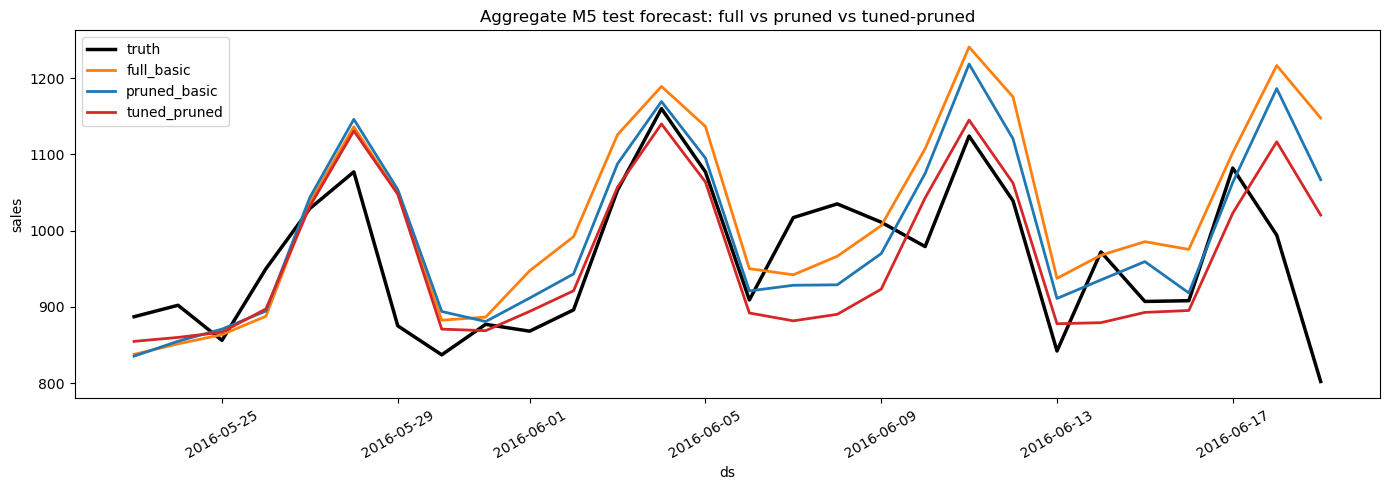

In [11]:
aggregate_eval = (
    test_eval.groupby('ds', as_index=False)[['y', 'full_basic', 'pruned_basic', 'tuned_pruned']]
    .sum()
)

plt.figure(figsize=(14, 5))
plt.plot(aggregate_eval['ds'], aggregate_eval['y'], color='black', linewidth=2.5, label='truth')
plt.plot(aggregate_eval['ds'], aggregate_eval['full_basic'], color='C1', linewidth=2, label='full_basic')
plt.plot(aggregate_eval['ds'], aggregate_eval['pruned_basic'], color='C0', linewidth=2, label='pruned_basic')
plt.plot(aggregate_eval['ds'], aggregate_eval['tuned_pruned'], color='C3', linewidth=2, label='tuned_pruned')
plt.title('Aggregate M5 test forecast: full vs pruned vs tuned-pruned')
plt.xlabel('ds')
plt.ylabel('sales')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_90658/892411202.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby('unique_id', as_index=False)['y']


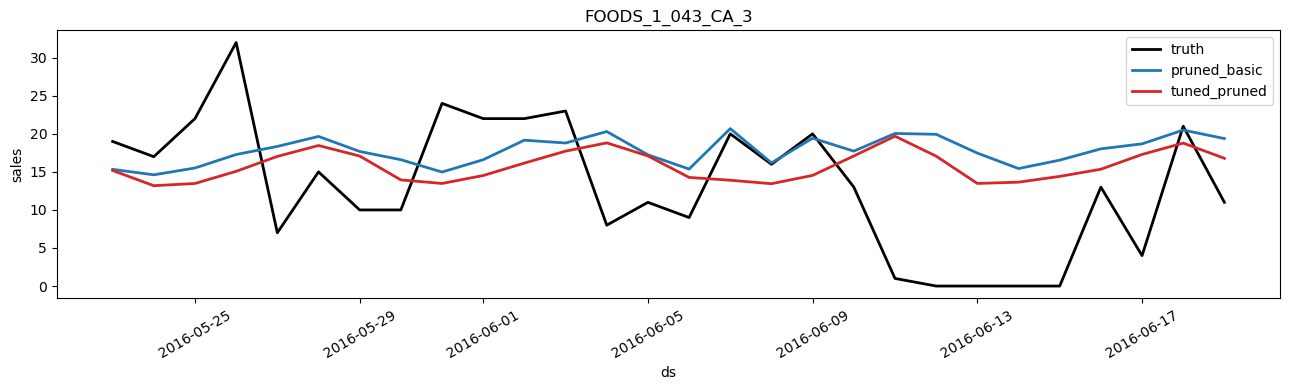

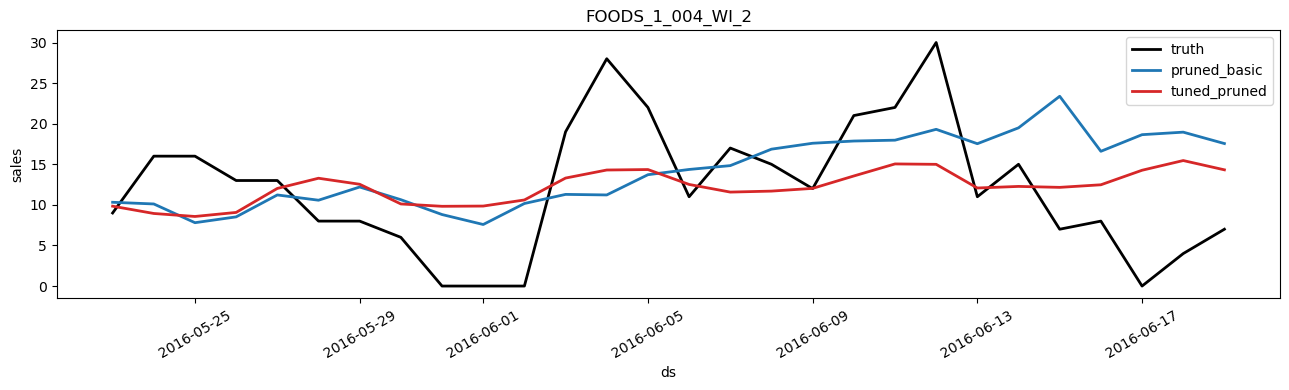

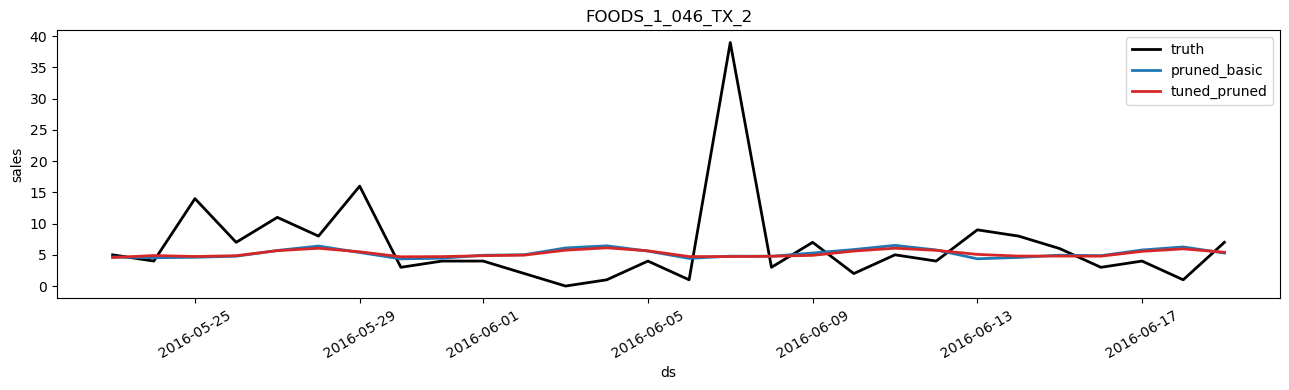

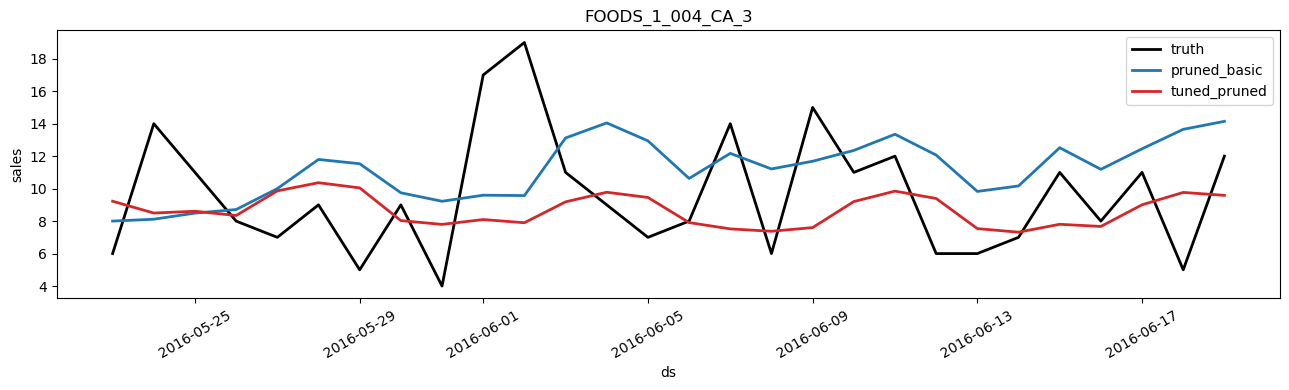

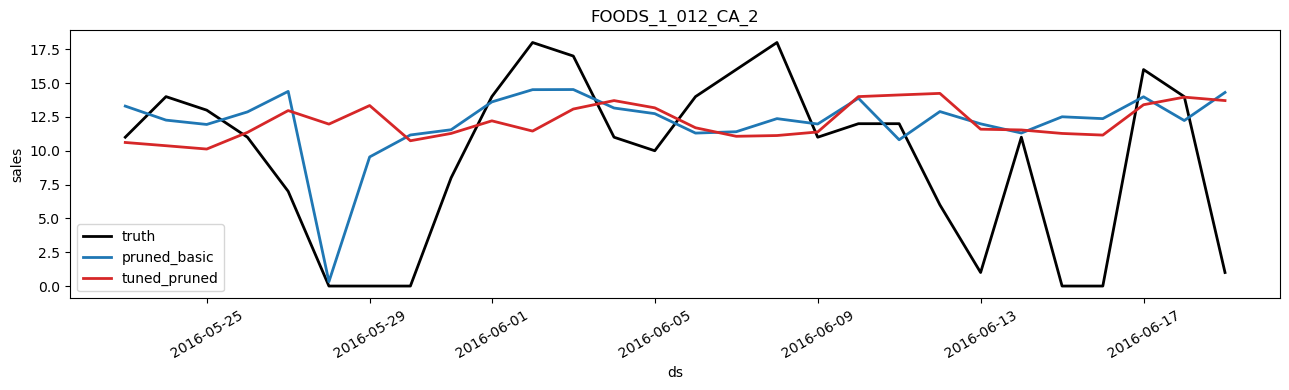

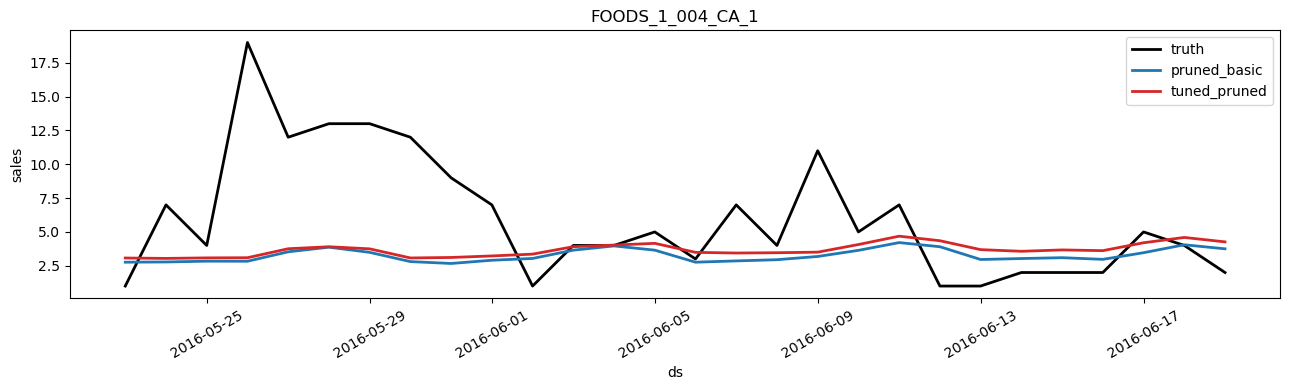

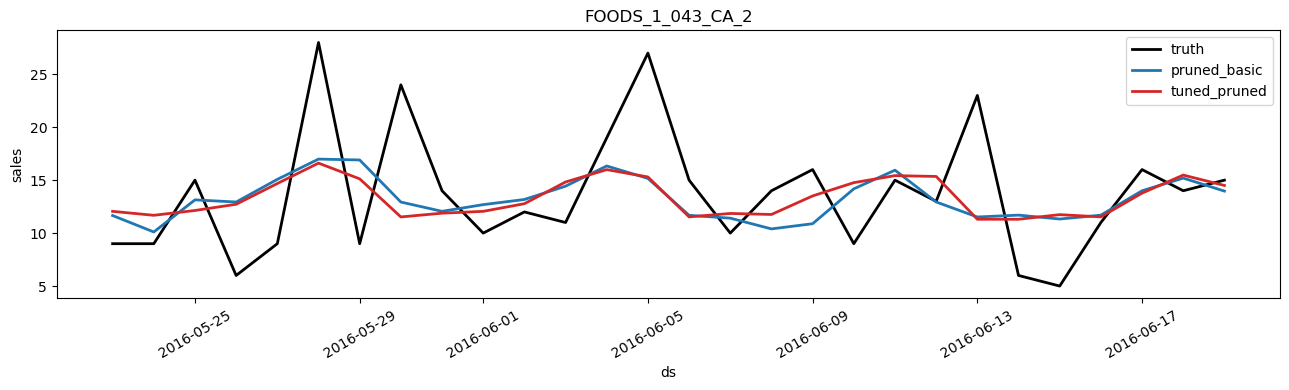

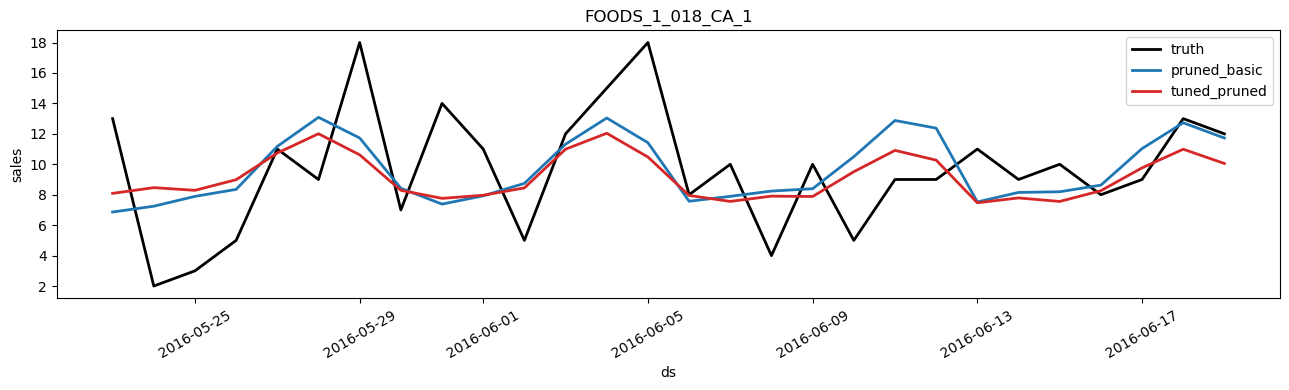

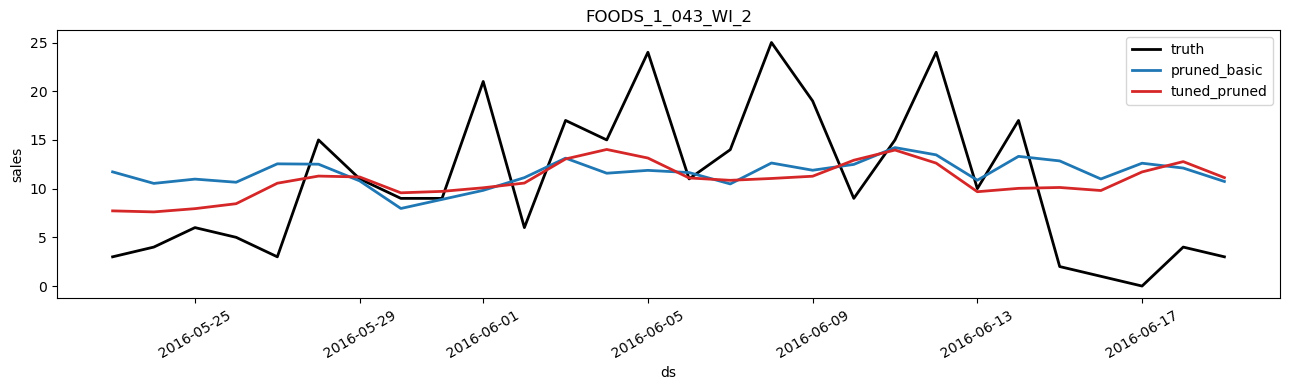

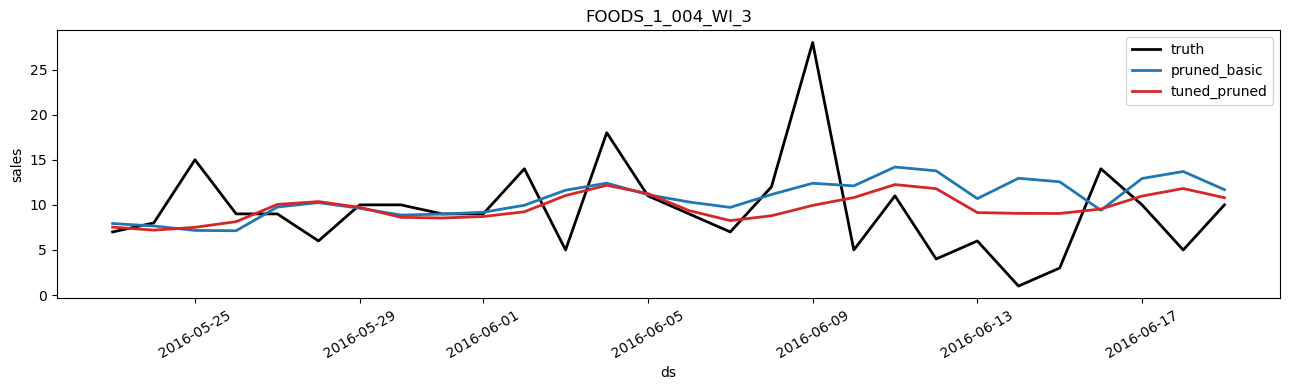

In [12]:
ranking = (
    train_df.groupby('unique_id', as_index=False)['y']
    .mean()
    .rename(columns={'y': 'mean_daily_sales'})
    .sort_values('mean_daily_sales', ascending=False)
)
plot_top_ids(
    test_eval_df=test_eval,
    baseline_col='pruned_basic',
    tuned_col='tuned_pruned',
    ranking=ranking,
    n_ids=PLOT_N_IDS,
)
